# Last-7-Day Patient Classification — 32/64/128-dim × 7 Days Features

**Goal**: Classify label 0 vs label 1 using the full 7-day history per patient.
Runs for embed_dim ∈ {32, 64, 128} — each produces a separate result set.

**Approach**:
```
Day 0 embedding [D-dim] \
Day 1 embedding [D-dim]  \
Day 2 embedding [D-dim]   → concatenate → [7D-dim] → LR/SVM/DT/RF/XGB → label 0/1
...                        /
Day 6 embedding [D-dim] /
```

Each patient = one 7D-dim feature vector. Missing days → zero-padded.
Train/val/test split at patient level (no leakage).

**Models**: LR, SVM, DT, RF (fine-tuned), XGBoost (fine-tuned).

**Save folders**:
- `daily_embedding_classifier_last7days_32dim/classifier_results/`
- `daily_embedding_classifier_last7days_64dim/classifier_results/`
- `daily_embedding_classifier_last7days_128dim/classifier_results/`


---
## Step 1 — Install & Import

In [ ]:
!pip install -q xgboost scikit-learn imbalanced-learn tqdm


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tqdm.auto import tqdm
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, make_scorer
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, LeaveOneGroupOut, cross_val_score
)
from scipy.stats import randint, uniform
import xgboost as xgb

print('All imports OK')


All imports OK


---
## Step 2 — Mount Drive & Set Embedding Paths

Embeddings for each dim are loaded inside the main loop (Step 3+).
Set `BASE_MODEL_DIR` to the folder containing your dim subfolders.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Folder structure ─────────────────────────────────────────────────────────
# Best_Model/
#   daily_embedding_classifier_last7days_32dim/   ← transformer embeddings
#   daily_embedding_classifier_last7days_64dim/
#   daily_embedding_classifier_last7days_128dim/
#   5models/                                       ← NEW: classifier models
#     last7days/
#       32dim/
#         xgboost/         model.joblib + best_params.json + metrics.json
#         logistic_regression/
#         random_forest/
#         svm/
#         decision_tree/
#         pca_xgboost/
#       64dim/  ...
#       128dim/ ...

BASE_MODEL_DIR  = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model"
MODELS_ROOT     = os.path.join(BASE_MODEL_DIR, 'classifier_5models', 'last7days_withtime')
ALL_DAYS        = list(range(7))   # 0..6
EMBED_DIMS      = [32, 64, 128]

# Pre-create all dim + model subfolders
MODEL_NAMES = ['xgboost', 'logistic_regression', 'random_forest',
               'svm', 'decision_tree', 'pca_xgboost']
for dim in EMBED_DIMS:
    for mname in MODEL_NAMES:
        os.makedirs(os.path.join(MODELS_ROOT, f'{dim}dim', mname), exist_ok=True)

print(f'Base model dir : {BASE_MODEL_DIR}')
print(f'Models root    : {MODELS_ROOT}')
print(f'Embed dims     : {EMBED_DIMS}')
print(f'\nFolder structure created:')
for dim in EMBED_DIMS:
    for mname in MODEL_NAMES:
        print(f'  5models/last7days_withtime/{dim}dim/{mname}/')


Mounted at /content/drive
Base model dir : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model
Models root    : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/classifier_5models/last7days_withtime
Embed dims     : [32, 64, 128]

Folder structure created:
  5models/last7days/32dim/xgboost/
  5models/last7days/32dim/logistic_regression/
  5models/last7days/32dim/random_forest/
  5models/last7days/32dim/svm/
  5models/last7days/32dim/decision_tree/
  5models/last7days/32dim/pca_xgboost/
  5models/last7days/64dim/xgboost/
  5models/last7days/64dim/logistic_regression/
  5models/last7days/64dim/random_forest/
  5models/last7days/64dim/svm/
  5models/last7days/64dim/decision_tree/
  5models/last7days/64dim/pca_xgboost/
  5models/last7days/128dim/xgboost/
  5models/last7days/128dim/logistic_regression/
  5models/last7days/128dim/random_forest/
  5models/last7days/128dim/svm/
  5models/last7days/128dim/decision_tree/
  5models/last7days/128dim/p

---
## Step 3 — Evaluation Helpers (shared across all dims)

Define `build_patient_features`, `plot_cm`, and `evaluate` once.
The main training loop (Step 4) calls these for each embed_dim.


In [ ]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, make_scorer
)
from matplotlib.colors import LinearSegmentedColormap

f1_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)
CV        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
LABELS    = ['Label 0 (healthy)', 'Label 1 (hospital)']
blue_cmap = LinearSegmentedColormap.from_list(
    'blue_cm', ['#EBF5FB', '#1A5276'], N=256)


def build_patient_features(emb_df, emb_cols, emb_dim):
    """
    One row per patient = concatenated embeddings for days 0..6.
    Missing days → zero-padded.
    Returns X [n_patients, 7*emb_dim], y [n_patients], patient_ids.
    """
    patient_ids = emb_df['patient_id'].unique()
    X_rows, y_rows, pids_out = [], [], []
    for pid in patient_ids:
        sub   = emb_df[emb_df['patient_id'] == pid]
        label = int(sub['label'].iloc[0])
        day_vecs = []
        for d in ALL_DAYS:
            rows = sub[sub['unified_day'] == d]
            if len(rows) > 0:
                vec = rows[emb_cols].values.mean(axis=0).astype(np.float32)
            else:
                vec = np.zeros(emb_dim, dtype=np.float32)
            day_vecs.append(vec)
        X_rows.append(np.concatenate(day_vecs))
        y_rows.append(label)
        pids_out.append(pid)
    return np.array(X_rows), np.array(y_rows), np.array(pids_out)


def plot_cm(ax, cm, title):
    ax.imshow(cm, interpolation='nearest', cmap=blue_cmap)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Label 0','Label 1'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Label 0','Label 1'])
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > thresh else '#1A5276'
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)


def evaluate(clf, model_name, save_name, out_dir,
             X_tr, y_tr, pids_tr,
             X_va, y_va, pids_va,
             X_te, y_te, pids_te):
    """Evaluate on train/val/test. Returns metrics dict."""
    print('\n' + '='*60)
    print(f'{model_name} — Evaluation')
    print('='*60)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(f'{model_name} — Confusion Matrices', fontsize=12)

    metrics = {}
    for ax, (X, y, pids, split_name) in zip(axes, [
        (X_tr, y_tr, pids_tr, 'Train'),
        (X_va, y_va, pids_va, 'Val'),
        (X_te, y_te, pids_te, 'Test'),
    ]):
        try:    probs = clf.predict_proba(X)[:, 1]
        except: probs = clf.decision_function(X)
        preds = (probs >= 0.5).astype(int) if probs.min() >= 0 else clf.predict(X)
        try:    auc = roc_auc_score(y, probs)
        except: auc = float('nan')
        f1   = f1_score(y, preds, pos_label=1, zero_division=0)
        cm   = confusion_matrix(y, preds)
        acc  = accuracy_score(y, preds)
        acc0 = accuracy_score(y[y==0], preds[y==0]) if (y==0).sum()>0 else float('nan')
        acc1 = accuracy_score(y[y==1], preds[y==1]) if (y==1).sum()>0 else float('nan')

        print(f'\n── {split_name}  AUROC={auc:.4f}  F1(L1)={f1:.4f} ──')
        print(f'  Accuracy (combined): {acc:.4f}')
        print(f'  Accuracy (label 0) : {acc0:.4f}')
        print(f'  Accuracy (label 1) : {acc1:.4f}')
        print(classification_report(y, preds, target_names=LABELS, zero_division=0))
        print(f'  Confusion matrix:')
        print(f'              Pred 0   Pred 1')
        print(f'  True 0       {cm[0,0]:>5}    {cm[0,1]:>5}')
        print(f'  True 1       {cm[1,0]:>5}    {cm[1,1]:>5}')

        if split_name == 'Test':
            try:    prob_out = clf.predict_proba(X)[:, 1]
            except: prob_out = probs
            df_res = pd.DataFrame({
                'patient_id':  pids,
                'true_label':  y,
                'pred_label':  preds,
                'prob_label1': prob_out.round(3),
                'result': ['✅' if p==t else '❌' for p,t in zip(preds,y)]
            }).sort_values(['true_label','patient_id'])
            print(f'\n  Per-patient (test):')
            print(df_res.to_string(index=False))

        plot_cm(ax, cm, f'{split_name}\nAcc={acc:.3f}  F1={f1:.3f}')
        metrics[split_name] = {
            'auc':  round(auc,  4),
            'f1':   round(f1,   4),
            'acc':  round(acc,  4),
            'acc0': round(acc0, 4),
            'acc1': round(acc1, 4),
        }

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'cm_{save_name}.png'), dpi=120)
    plt.show()
    return metrics


print('Helpers ready: build_patient_features, plot_cm, evaluate')


Helpers ready: build_patient_features, plot_cm, evaluate


---
## Step 4 — Main Loop: Train 5 Models for each embed_dim (32 / 64 / 128)

For each dim:
1. Load embeddings from the dim's save folder
2. Build 7D-dim patient feature vectors
3. Train & fine-tune: XGBoost, LR, RF, SVM, DT
4. Run LOGO-CV on best models
5. Save confusion matrices, summary CSV, bar chart


Overall progress:   0%|          | 0/3 [00:00<?, ?dim/s]


██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 32  →  feature vector = 224 dims (32×7)
██████████████████████████████████████████████████████████████████████
  Loaded: train=(325, 35)  val=(100, 35)  test=(151, 35)
  Feature vector: 224 dims (32×7)
  Train: (48, 224)  Val: (15, 224)  Test: (22, 224)
  Label1 — train=18  val=5  test=5
  ✅ No patient leakage

  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...
  XGB-Random: 100 combos × 5 folds = 500 fits


  Fitting XGB-Random:   0%|          | 00:00

  ✅ Done in 22.1s  Best CV F1=0.8596
  Best params: {'colsample_bytree': np.float64(0.566854305569511), 'gamma': np.float64(0.28573363584388156), 'learning_rate': np.float64(0.07008884729488529), 'max_depth': 2, 'min_child_weight': 4, 'n_estimators': 393, 'reg_alpha': np.float64(2.497327922401265), 'reg_lambda': np.float64(4.185086660174142), 'subsample': np.float64(0.5909124836035503)}

  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...
  XGB-Fine: 512 combos × 5 folds = 2560 fits


  Fitting XGB-Fine:   0%|          | 00:00

  ✅ Done in 58.3s  Best CV F1=0.2000
  Best params: {'colsample_bytree': 0.5, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 8, 'subsample': 0.7}
  Using: random XGBoost

XGBoost (dim=32) — Evaluation

── Train  AUROC=0.9981  F1(L1)=0.9474 ──
  Accuracy (combined): 0.9583
  Accuracy (label 0) : 0.9333
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.93      0.97        30
Label 1 (hospital)       0.90      1.00      0.95        18

          accuracy                           0.96        48
         macro avg       0.95      0.97      0.96        48
      weighted avg       0.96      0.96      0.96        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          28        2
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy 

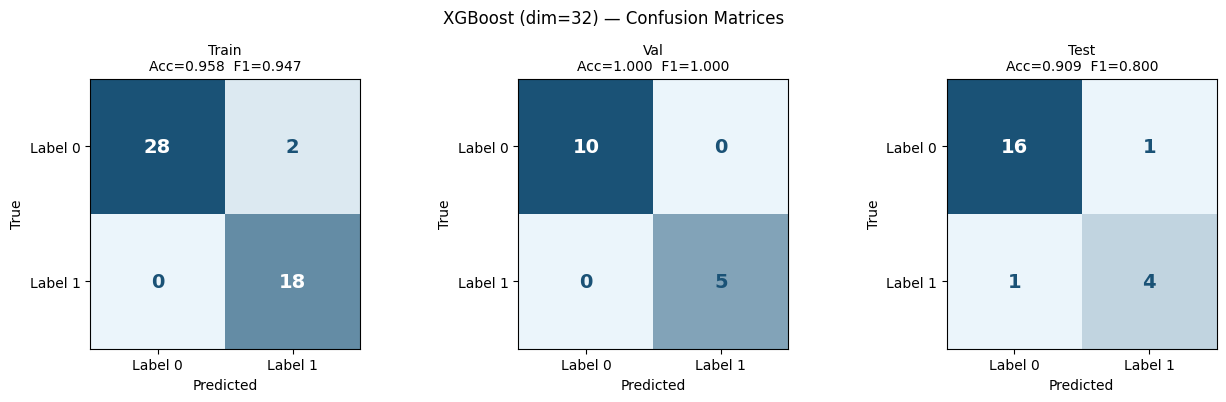


  ▶ Logistic Regression GridSearchCV (6 combos)...
  LR: 6 combos × 5 folds = 30 fits


  Fitting LR:   0%|          | 00:00

  ✅ Done in 0.3s  Best CV F1=0.8796
  Best params: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

Logistic Regression (dim=32) — Evaluation

── Train  AUROC=0.9963  F1(L1)=0.9474 ──
  Accuracy (combined): 0.9583
  Accuracy (label 0) : 0.9333
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.93      0.97        30
Label 1 (hospital)       0.90      1.00      0.95        18

          accuracy                           0.96        48
         macro avg       0.95      0.97      0.96        48
      weighted avg       0.96      0.96      0.96        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          28        2
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=0.9091 ──
  Accuracy (combined): 0.9333
  Accuracy (label 0) : 0.9000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.90      0.

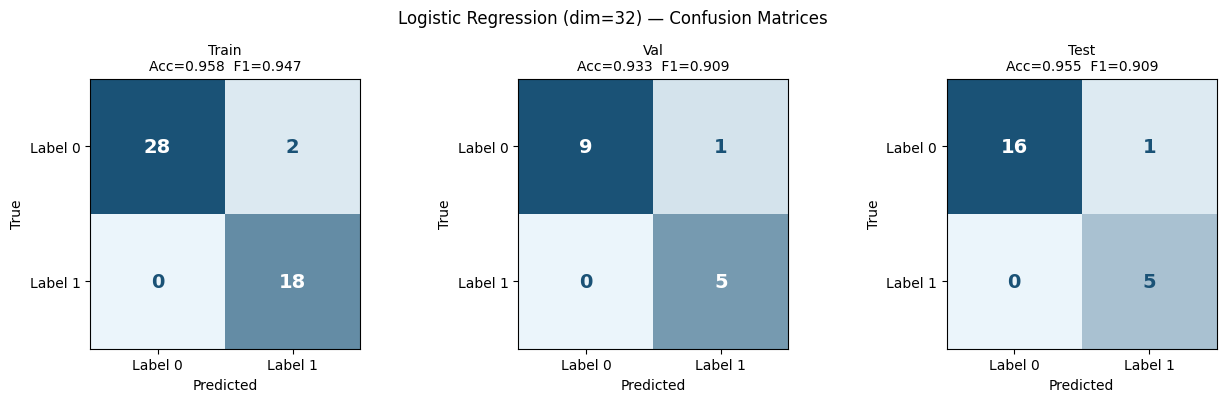


  ▶ Random Forest RandomizedSearchCV (100 iters)...
  RF-Random: 100 combos × 5 folds = 500 fits


  Fitting RF-Random:   0%|          | 00:00

  ✅ Done in 298.8s  Best CV F1=0.9333
  Best params: {'max_depth': None, 'max_features': 0.5, 'max_samples': np.float64(0.5115312125207079), 'min_samples_leaf': 11, 'min_samples_split': 11, 'n_estimators': 287}

Random Forest (dim=32) — Evaluation

── Train  AUROC=0.9889  F1(L1)=0.9231 ──
  Accuracy (combined): 0.9375
  Accuracy (label 0) : 0.9000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.90      0.95        30
Label 1 (hospital)       0.86      1.00      0.92        18

          accuracy                           0.94        48
         macro avg       0.93      0.95      0.94        48
      weighted avg       0.95      0.94      0.94        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          27        3
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=0.9091 ──
  Accuracy (combined): 0.9333
  Accuracy (label 0) : 0.9000
  Accuracy (label 1) : 1.0000
                 

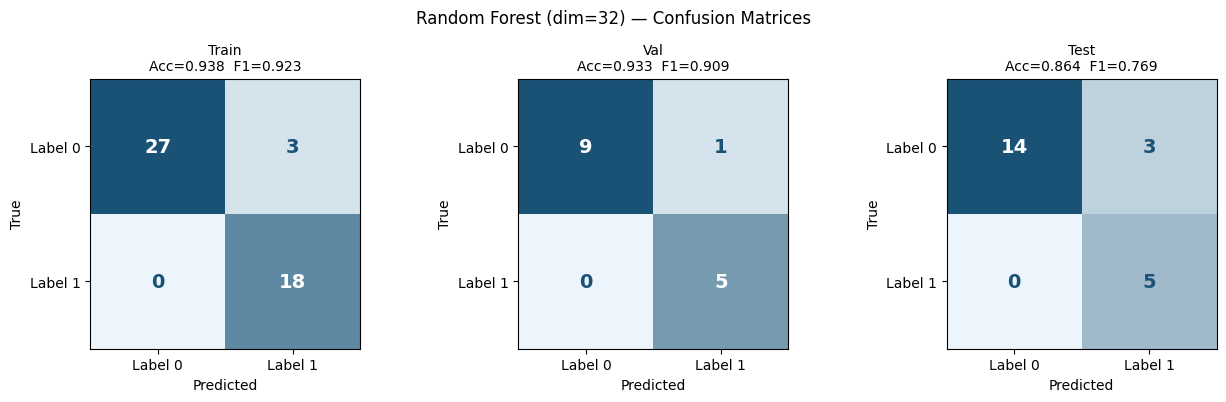


  ▶ SVM GridSearchCV (12 combos)...
  SVM: 12 combos × 5 folds = 60 fits


  Fitting SVM:   0%|          | 00:00

  ✅ Done in 0.4s  Best CV F1=0.8929
  Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

SVM (dim=32) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        10
La

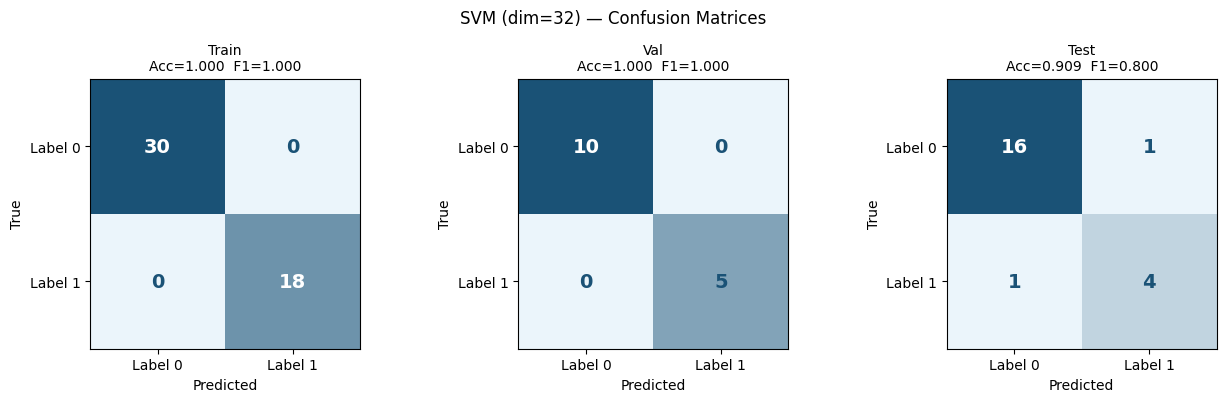


  ▶ Decision Tree GridSearchCV (24 combos)...
  DT: 24 combos × 5 folds = 120 fits


  Fitting DT:   0%|          | 00:00

  ✅ Done in 0.5s  Best CV F1=0.8374
  Best params: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5}

Decision Tree (dim=32) — Evaluation

── Train  AUROC=0.9880  F1(L1)=0.9189 ──
  Accuracy (combined): 0.9375
  Accuracy (label 0) : 0.9333
  Accuracy (label 1) : 0.9444
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.97      0.93      0.95        30
Label 1 (hospital)       0.89      0.94      0.92        18

          accuracy                           0.94        48
         macro avg       0.93      0.94      0.93        48
      weighted avg       0.94      0.94      0.94        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          28        2
  True 1           1       17

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support



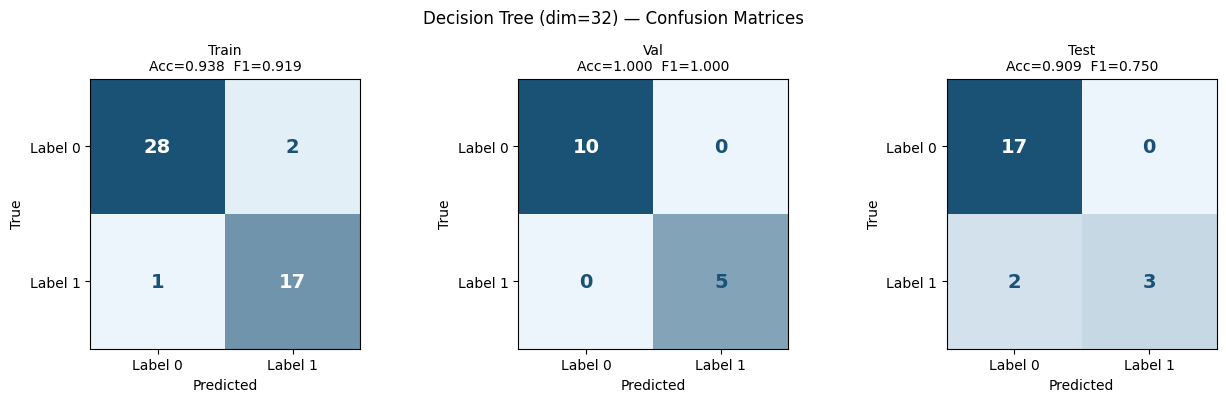


  ▶ PCA + XGBoost GridSearchCV (128 combos)...
  PCA+XGB: 128 combos × 5 folds = 640 fits


  Fitting PCA+XGB:   0%|          | 00:00

  ✅ Done in 13.5s  Best CV F1=0.7685
  Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_alpha': 2.0, 'clf__reg_lambda': 10, 'pca__n_components': 10}

PCA+XGBoost (dim=32) — Evaluation

── Train  AUROC=0.9907  F1(L1)=0.9189 ──
  Accuracy (combined): 0.9375
  Accuracy (label 0) : 0.9333
  Accuracy (label 1) : 0.9444
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.97      0.93      0.95        30
Label 1 (hospital)       0.89      0.94      0.92        18

          accuracy                           0.94        48
         macro avg       0.93      0.94      0.93        48
      weighted avg       0.94      0.94      0.94        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          28        2
  True 1           1       17

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
   

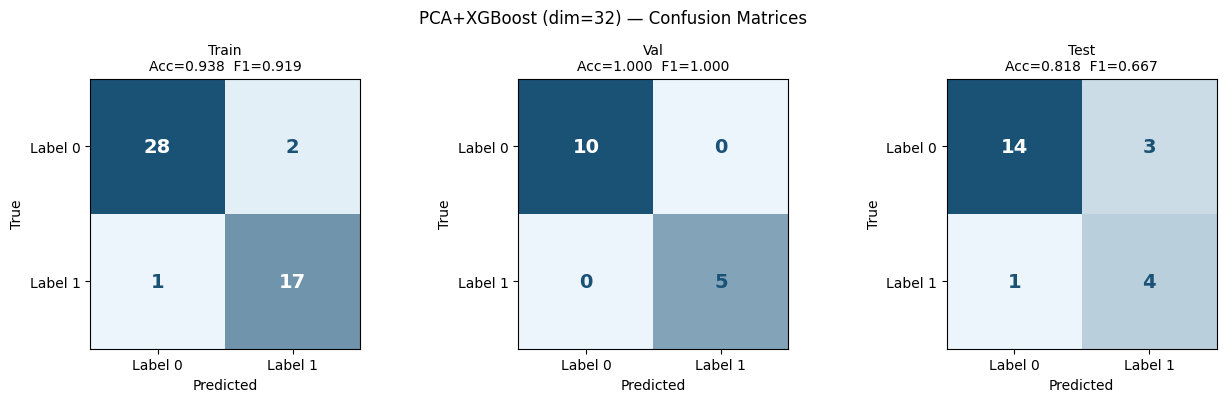

  ✅ Models captured for dim=32 → Step 5 can now save them

  ▶ Leave-One-Patient-Out CV...


  LOGO-CV:   0%|          | 0/6 [00:00<?, ?it/s]

  XGBoost          LOGO F1: 0.3176 ± 0.4656  min=0.000  max=1.000  (6.4s)
  LR               LOGO F1: 0.3176 ± 0.4656  min=0.000  max=1.000  (0.6s)
  RF               LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (46.0s)
  SVM              LOGO F1: 0.3176 ± 0.4656  min=0.000  max=1.000  (0.6s)
  DT               LOGO F1: 0.2941 ± 0.4556  min=0.000  max=1.000  (0.3s)
  PCA+XGBoost      LOGO F1: 0.2588 ± 0.4380  min=0.000  max=1.000  (3.7s)

  ACCURACY TABLE — dim=32  Train
Metric                  LR         SVM          DT          RF     XGBoost PCA+XGBoost
-----------------------------------------------------------------
Accuracy            0.9583      1.0000      0.9375      0.9375      0.9583      0.9375
Acc L0              0.9333      1.0000      0.9333      0.9000      0.9333      0.9333
Acc L1              1.0000      1.0000      0.9444      1.0000      1.0000      0.9444
F1 (L1)             0.9474      1.0000      0.9189      0.9231      0.9474      0.9189
AUROC               

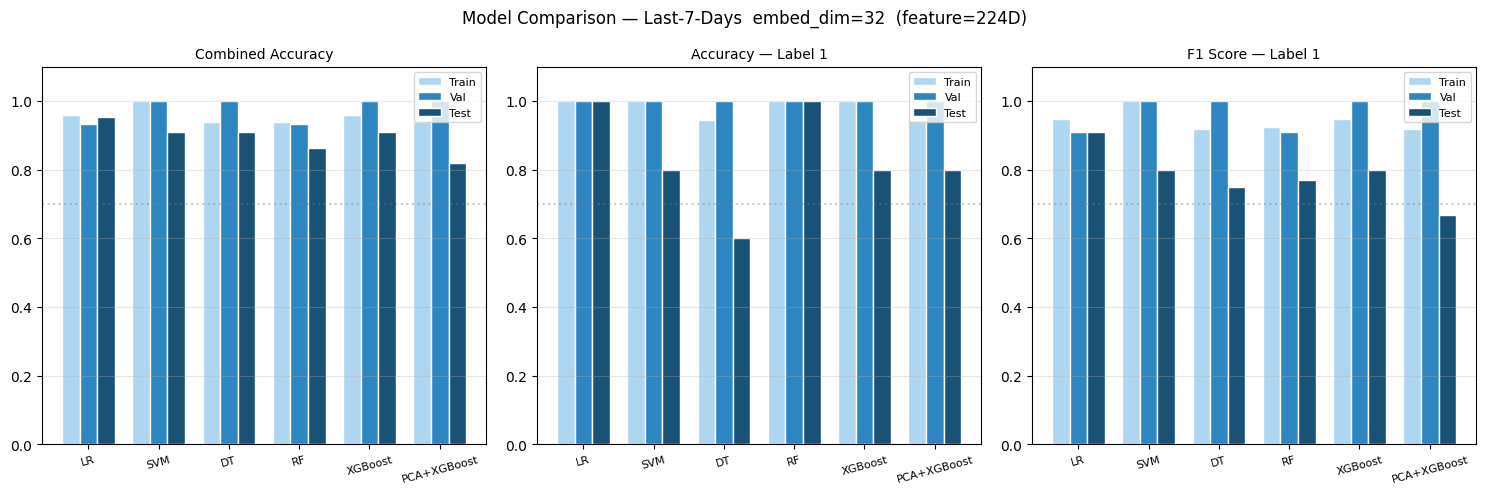


  ✅ Best model (dim=32) by val F1: SVM
     Val F1=1.0000  LOGO F1=0.3176  Total time: 7.7 min

██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 64  →  feature vector = 448 dims (64×7)
██████████████████████████████████████████████████████████████████████
  Loaded: train=(325, 67)  val=(100, 67)  test=(151, 67)
  Feature vector: 448 dims (64×7)
  Train: (48, 448)  Val: (15, 448)  Test: (22, 448)
  Label1 — train=18  val=5  test=5
  ✅ No patient leakage

  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...
  XGB-Random: 100 combos × 5 folds = 500 fits


  Fitting XGB-Random:   0%|          | 00:00

  ✅ Done in 27.0s  Best CV F1=1.0000
  Best params: {'colsample_bytree': np.float64(0.566854305569511), 'gamma': np.float64(0.28573363584388156), 'learning_rate': np.float64(0.07008884729488529), 'max_depth': 2, 'min_child_weight': 4, 'n_estimators': 393, 'reg_alpha': np.float64(2.497327922401265), 'reg_lambda': np.float64(4.185086660174142), 'subsample': np.float64(0.5909124836035503)}

  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...
  XGB-Fine: 512 combos × 5 folds = 2560 fits


  Fitting XGB-Fine:   0%|          | 00:00

  ✅ Done in 80.6s  Best CV F1=0.2000
  Best params: {'colsample_bytree': 0.5, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 8, 'subsample': 0.7}
  Using: random XGBoost

XGBoost (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy 

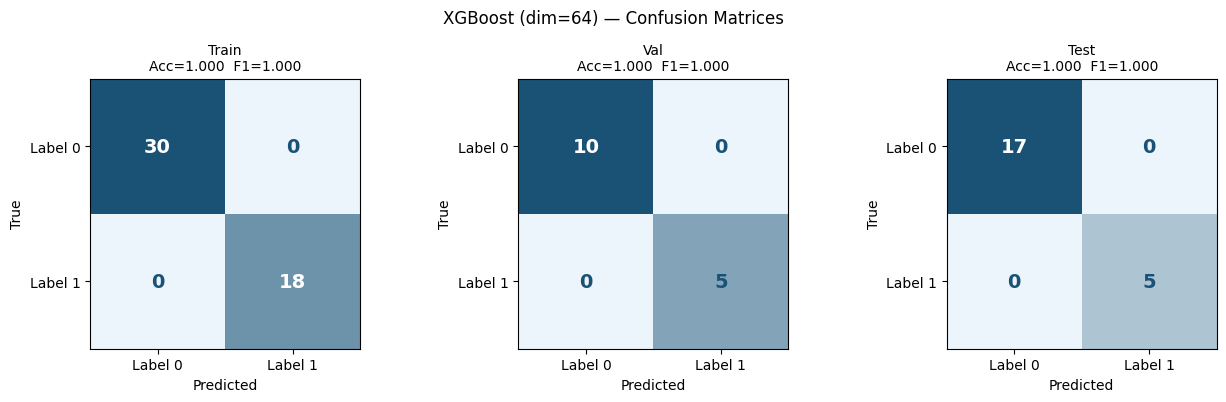


  ▶ Logistic Regression GridSearchCV (6 combos)...
  LR: 6 combos × 5 folds = 30 fits


  Fitting LR:   0%|          | 00:00

  ✅ Done in 0.3s  Best CV F1=1.0000
  Best params: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

Logistic Regression (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.

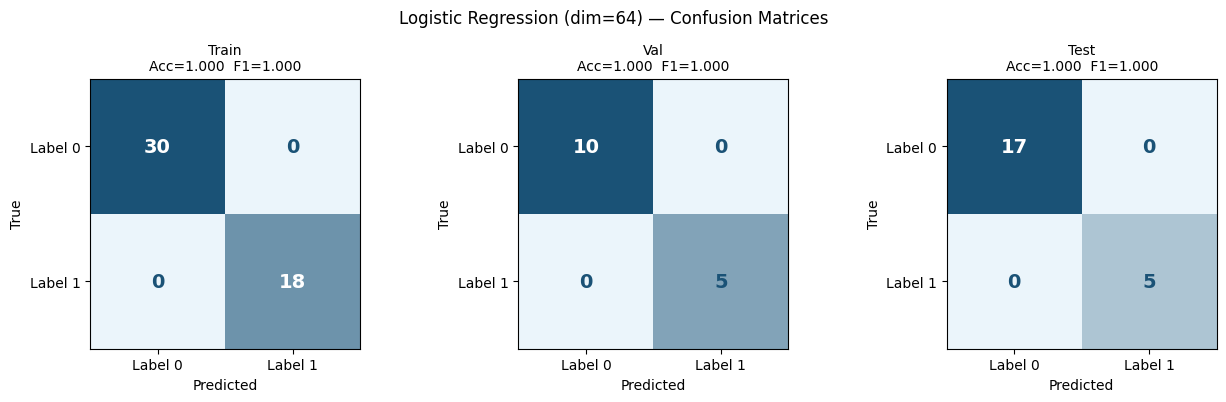


  ▶ Random Forest RandomizedSearchCV (100 iters)...
  RF-Random: 100 combos × 5 folds = 500 fits


  Fitting RF-Random:   0%|          | 00:00

  ✅ Done in 284.8s  Best CV F1=1.0000
  Best params: {'max_depth': 6, 'max_features': 'sqrt', 'max_samples': np.float64(0.5917173949330818), 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 221}

Random Forest (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                   

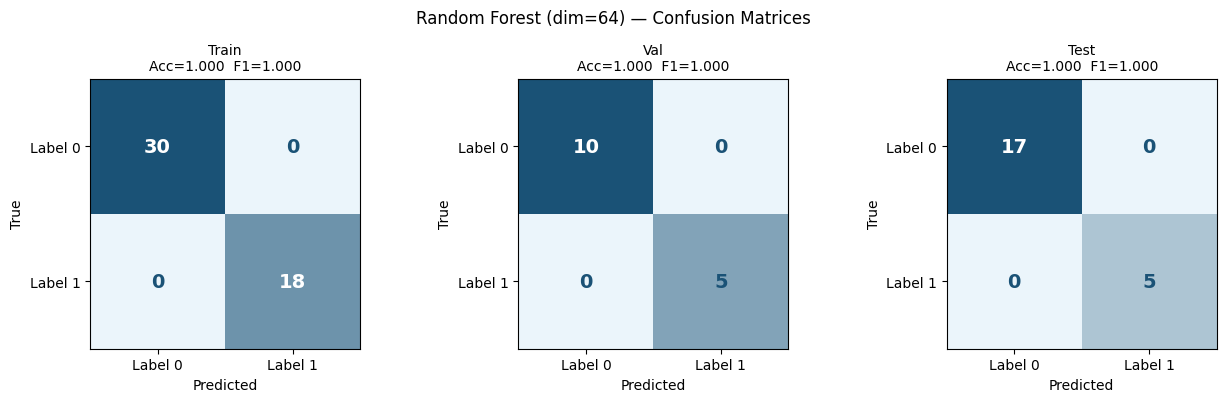


  ▶ SVM GridSearchCV (12 combos)...
  SVM: 12 combos × 5 folds = 60 fits


  Fitting SVM:   0%|          | 00:00

  ✅ Done in 0.6s  Best CV F1=1.0000
  Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

SVM (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        10
La

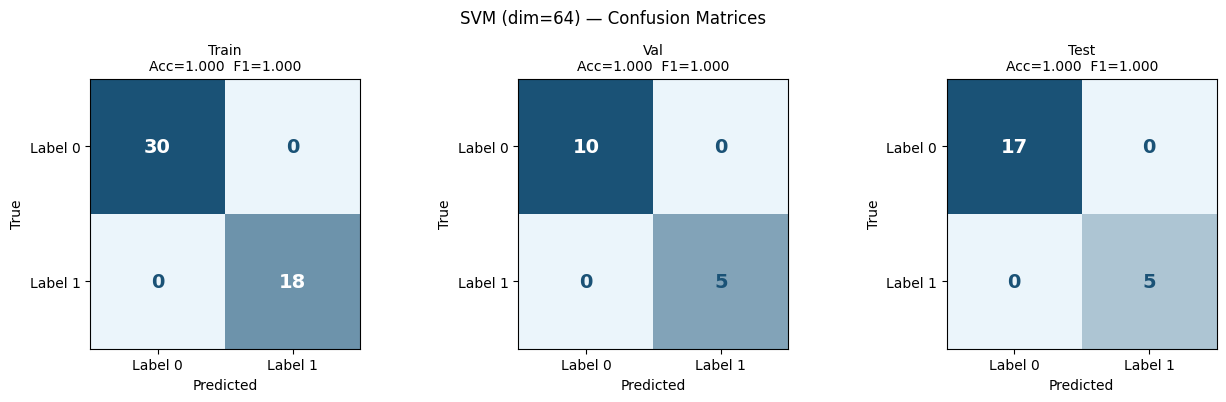


  ▶ Decision Tree GridSearchCV (24 combos)...
  DT: 24 combos × 5 folds = 120 fits


  Fitting DT:   0%|          | 00:00

  ✅ Done in 0.5s  Best CV F1=1.0000
  Best params: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5}

Decision Tree (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support



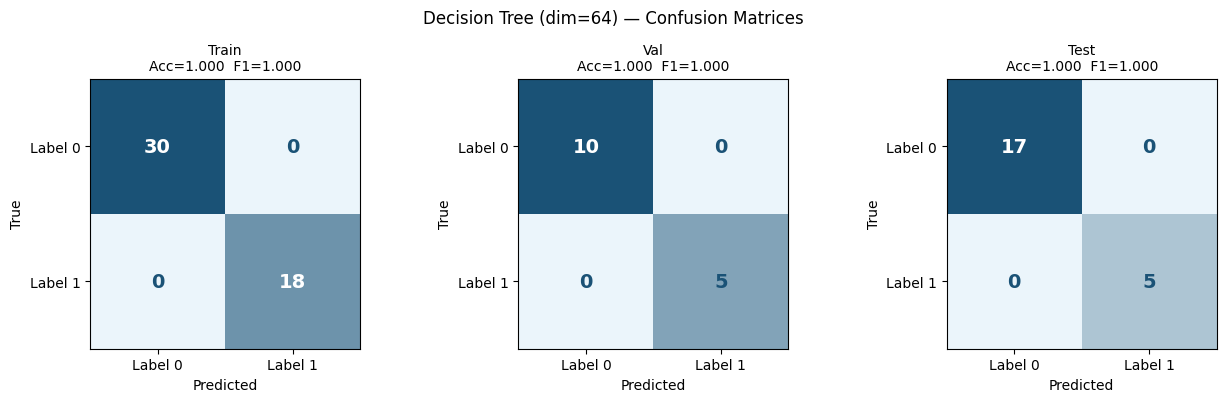


  ▶ PCA + XGBoost GridSearchCV (128 combos)...
  PCA+XGB: 128 combos × 5 folds = 640 fits


  Fitting PCA+XGB:   0%|          | 00:00

  ✅ Done in 13.9s  Best CV F1=0.7486
  Best params: {'clf__learning_rate': 0.01, 'clf__max_depth': 2, 'clf__min_child_weight': 5, 'clf__n_estimators': 100, 'clf__reg_alpha': 0.5, 'clf__reg_lambda': 5, 'pca__n_components': 10}

PCA+XGBoost (dim=64) — Evaluation

── Train  AUROC=0.9833  F1(L1)=0.9730 ──
  Accuracy (combined): 0.9792
  Accuracy (label 0) : 0.9667
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.97      0.98        30
Label 1 (hospital)       0.95      1.00      0.97        18

          accuracy                           0.98        48
         macro avg       0.97      0.98      0.98        48
      weighted avg       0.98      0.98      0.98        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          29        1
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
    

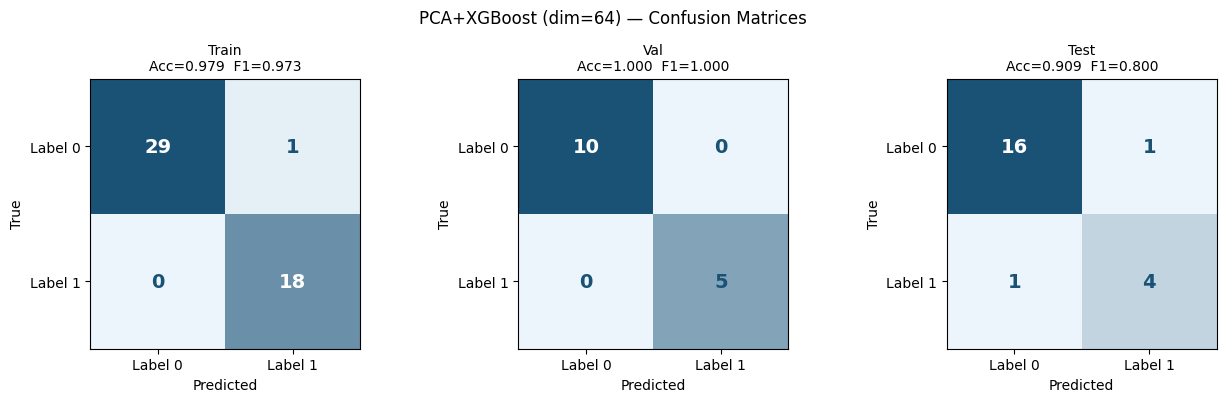

  ✅ Models captured for dim=64 → Step 5 can now save them

  ▶ Leave-One-Patient-Out CV...


  LOGO-CV:   0%|          | 0/6 [00:00<?, ?it/s]

  XGBoost          LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (8.7s)
  LR               LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (0.8s)
  RF               LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (32.1s)
  SVM              LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (0.9s)
  DT               LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (0.5s)
  PCA+XGBoost      LOGO F1: 0.3059 ± 0.4608  min=0.000  max=1.000  (2.0s)

  ACCURACY TABLE — dim=64  Train
Metric                  LR         SVM          DT          RF     XGBoost PCA+XGBoost
-----------------------------------------------------------------
Accuracy            1.0000      1.0000      1.0000      1.0000      1.0000      0.9792
Acc L0              1.0000      1.0000      1.0000      1.0000      1.0000      0.9667
Acc L1              1.0000      1.0000      1.0000      1.0000      1.0000      1.0000
F1 (L1)             1.0000      1.0000      1.0000      1.0000      1.0000      0.9730
AUROC               

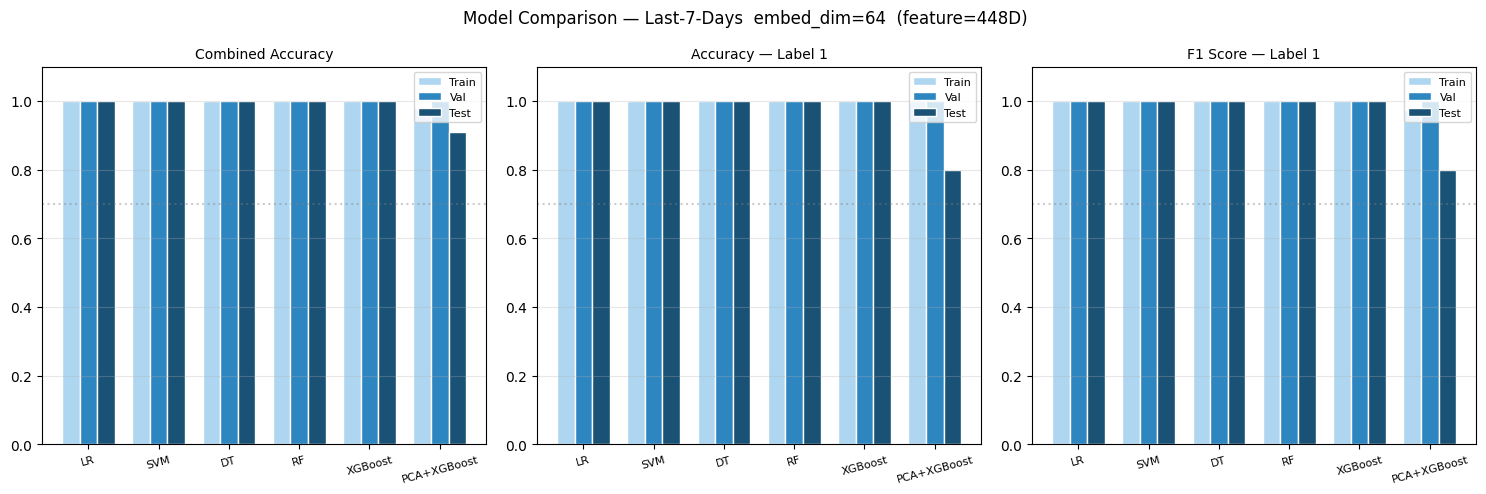


  ✅ Best model (dim=64) by val F1: LR
     Val F1=1.0000  LOGO F1=0.3294  Total time: 7.7 min

██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 128  →  feature vector = 896 dims (128×7)
██████████████████████████████████████████████████████████████████████
  Loaded: train=(325, 131)  val=(100, 131)  test=(151, 131)
  Feature vector: 896 dims (128×7)
  Train: (48, 896)  Val: (15, 896)  Test: (22, 896)
  Label1 — train=18  val=5  test=5
  ✅ No patient leakage

  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...
  XGB-Random: 100 combos × 5 folds = 500 fits


  Fitting XGB-Random:   0%|          | 00:00

  ✅ Done in 43.2s  Best CV F1=1.0000
  Best params: {'colsample_bytree': np.float64(0.566854305569511), 'gamma': np.float64(0.28573363584388156), 'learning_rate': np.float64(0.07008884729488529), 'max_depth': 2, 'min_child_weight': 4, 'n_estimators': 393, 'reg_alpha': np.float64(2.497327922401265), 'reg_lambda': np.float64(4.185086660174142), 'subsample': np.float64(0.5909124836035503)}

  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...
  XGB-Fine: 512 combos × 5 folds = 2560 fits


  Fitting XGB-Fine:   0%|          | 00:00

  ✅ Done in 132.3s  Best CV F1=0.2000
  Best params: {'colsample_bytree': 0.5, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 8, 'subsample': 0.7}
  Using: random XGBoost

XGBoost (dim=128) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accurac

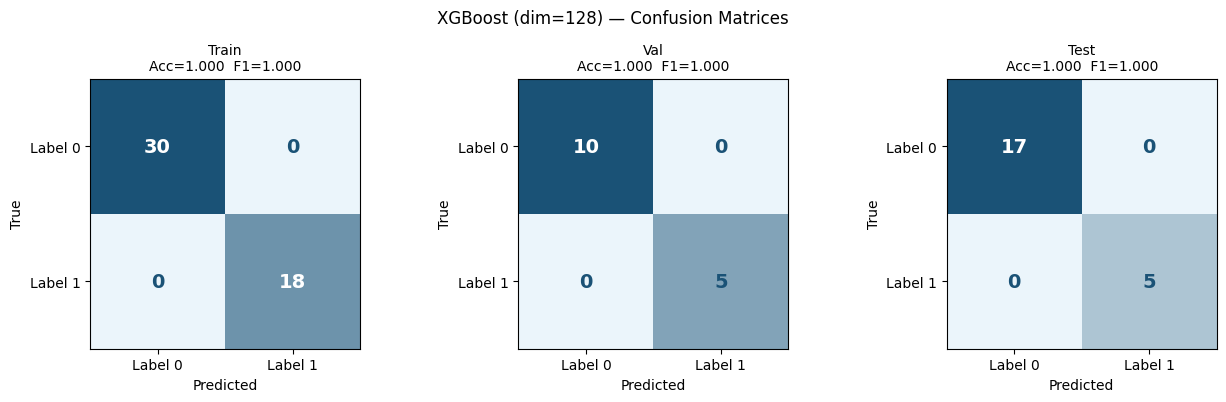


  ▶ Logistic Regression GridSearchCV (6 combos)...
  LR: 6 combos × 5 folds = 30 fits


  Fitting LR:   0%|          | 00:00

  ✅ Done in 0.4s  Best CV F1=0.9596
  Best params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

Logistic Regression (dim=128) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00    

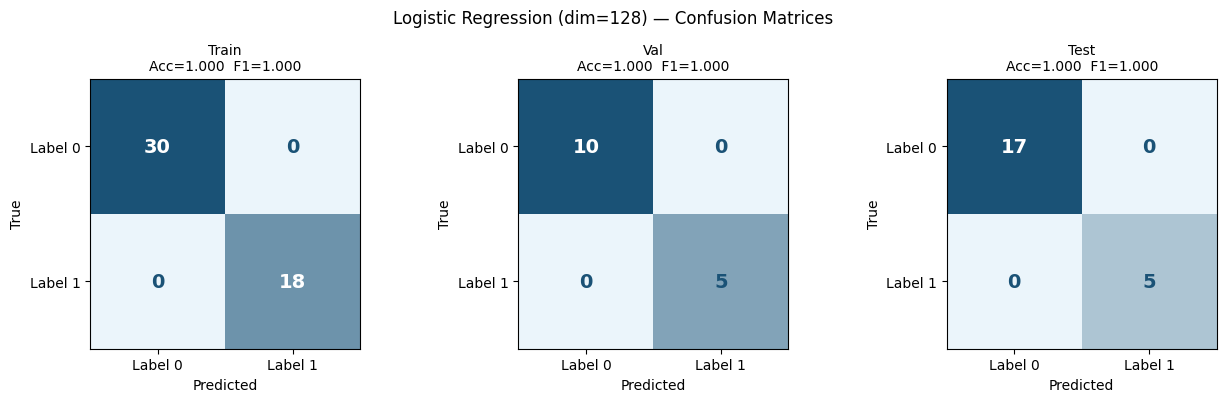


  ▶ Random Forest RandomizedSearchCV (100 iters)...
  RF-Random: 100 combos × 5 folds = 500 fits


  Fitting RF-Random:   0%|          | 00:00

  ✅ Done in 324.1s  Best CV F1=1.0000
  Best params: {'max_depth': 5, 'max_features': 0.3, 'max_samples': np.float64(0.5290418060840998), 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 459}

Random Forest (dim=128) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    p

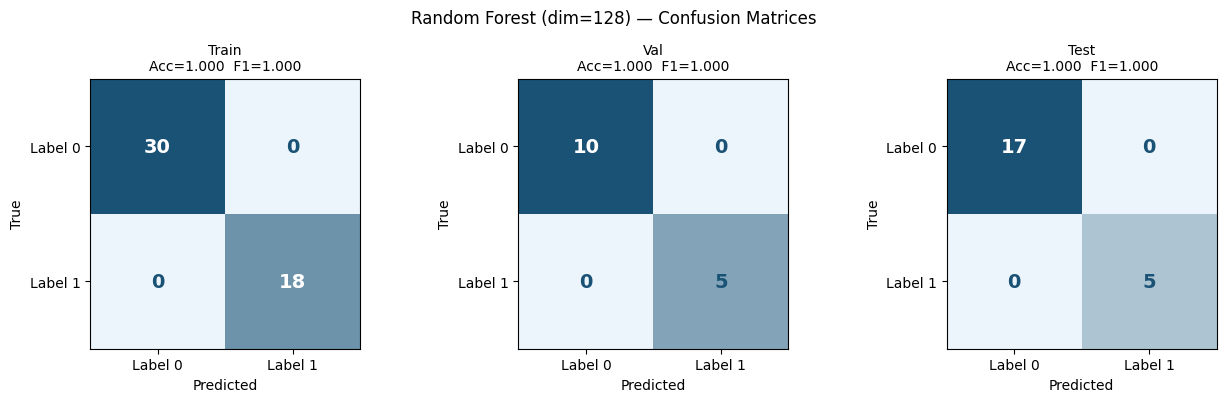


  ▶ SVM GridSearchCV (12 combos)...
  SVM: 12 combos × 5 folds = 60 fits


  Fitting SVM:   0%|          | 00:00

  ✅ Done in 0.7s  Best CV F1=0.9778
  Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

SVM (dim=128) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        10
L

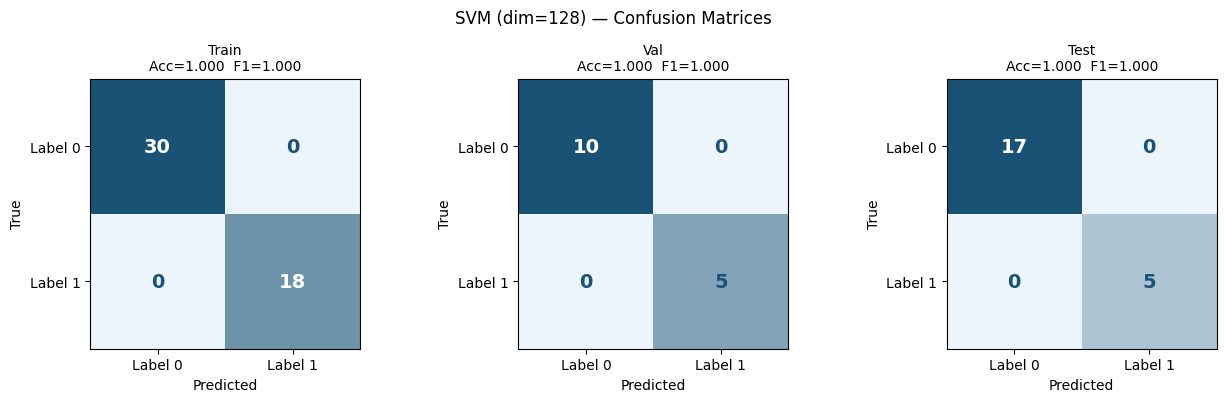


  ▶ Decision Tree GridSearchCV (24 combos)...
  DT: 24 combos × 5 folds = 120 fits


  Fitting DT:   0%|          | 00:00

  ✅ Done in 0.6s  Best CV F1=0.7911
  Best params: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5}

Decision Tree (dim=128) — Evaluation

── Train  AUROC=0.9926  F1(L1)=0.9000 ──
  Accuracy (combined): 0.9167
  Accuracy (label 0) : 0.8667
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.87      0.93        30
Label 1 (hospital)       0.82      1.00      0.90        18

          accuracy                           0.92        48
         macro avg       0.91      0.93      0.91        48
      weighted avg       0.93      0.92      0.92        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          26        4
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support


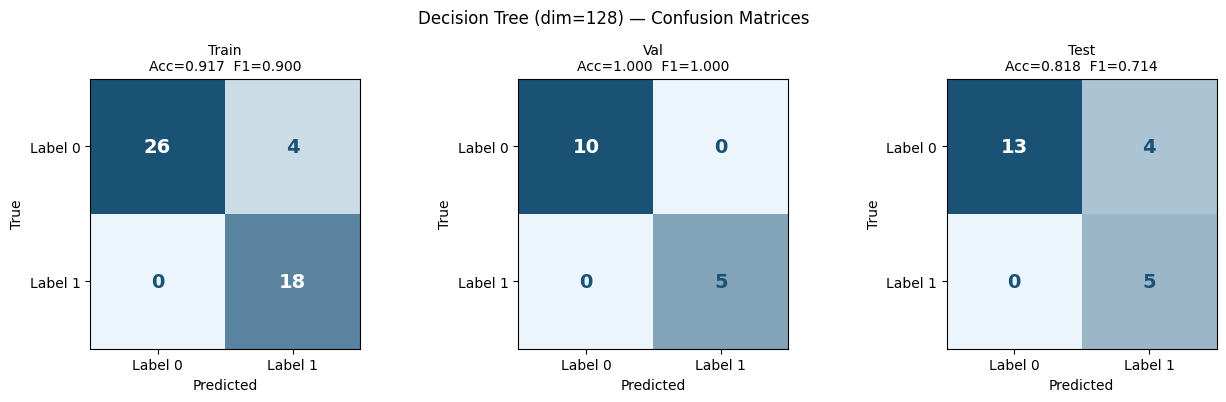


  ▶ PCA + XGBoost GridSearchCV (128 combos)...
  PCA+XGB: 128 combos × 5 folds = 640 fits


  Fitting PCA+XGB:   0%|          | 00:00

  ✅ Done in 15.3s  Best CV F1=0.7448
  Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_alpha': 2.0, 'clf__reg_lambda': 5, 'pca__n_components': 20}

PCA+XGBoost (dim=128) — Evaluation

── Train  AUROC=1.0000  F1(L1)=0.9730 ──
  Accuracy (combined): 0.9792
  Accuracy (label 0) : 0.9667
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.97      0.98        30
Label 1 (hospital)       0.95      1.00      0.97        18

          accuracy                           0.98        48
         macro avg       0.97      0.98      0.98        48
      weighted avg       0.98      0.98      0.98        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          29        1
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=0.8889 ──
  Accuracy (combined): 0.9333
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 0.8000
   

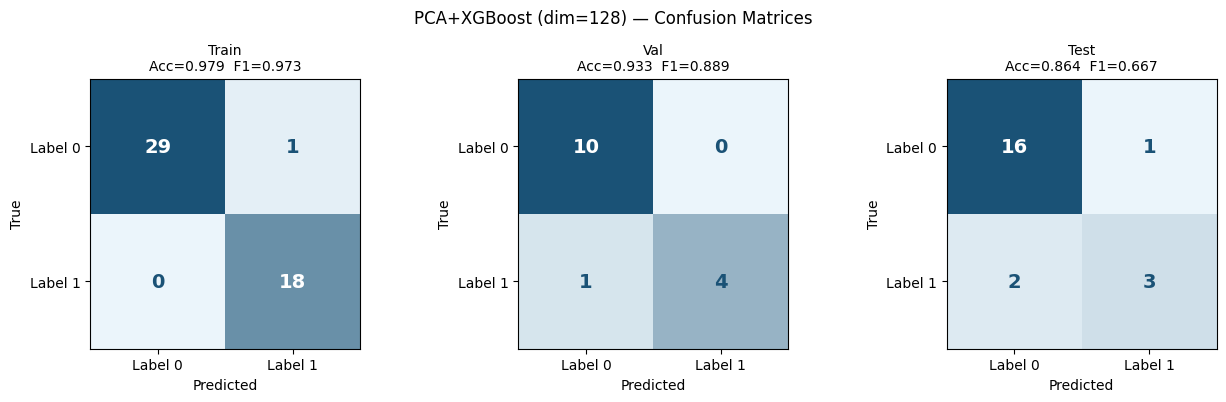

  ✅ Models captured for dim=128 → Step 5 can now save them

  ▶ Leave-One-Patient-Out CV...


  LOGO-CV:   0%|          | 0/6 [00:00<?, ?it/s]

  XGBoost          LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (19.9s)
  LR               LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (1.4s)
  RF               LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (94.5s)
  SVM              LOGO F1: 0.3294 ± 0.4700  min=0.000  max=1.000  (1.0s)
  DT               LOGO F1: 0.2941 ± 0.4556  min=0.000  max=1.000  (0.4s)
  PCA+XGBoost      LOGO F1: 0.2706 ± 0.4443  min=0.000  max=1.000  (3.4s)

  ACCURACY TABLE — dim=128  Train
Metric                  LR         SVM          DT          RF     XGBoost PCA+XGBoost
-----------------------------------------------------------------
Accuracy            1.0000      1.0000      0.9167      1.0000      1.0000      0.9792
Acc L0              1.0000      1.0000      0.8667      1.0000      1.0000      0.9667
Acc L1              1.0000      1.0000      1.0000      1.0000      1.0000      1.0000
F1 (L1)             1.0000      1.0000      0.9000      1.0000      1.0000      0.9730
AUROC             

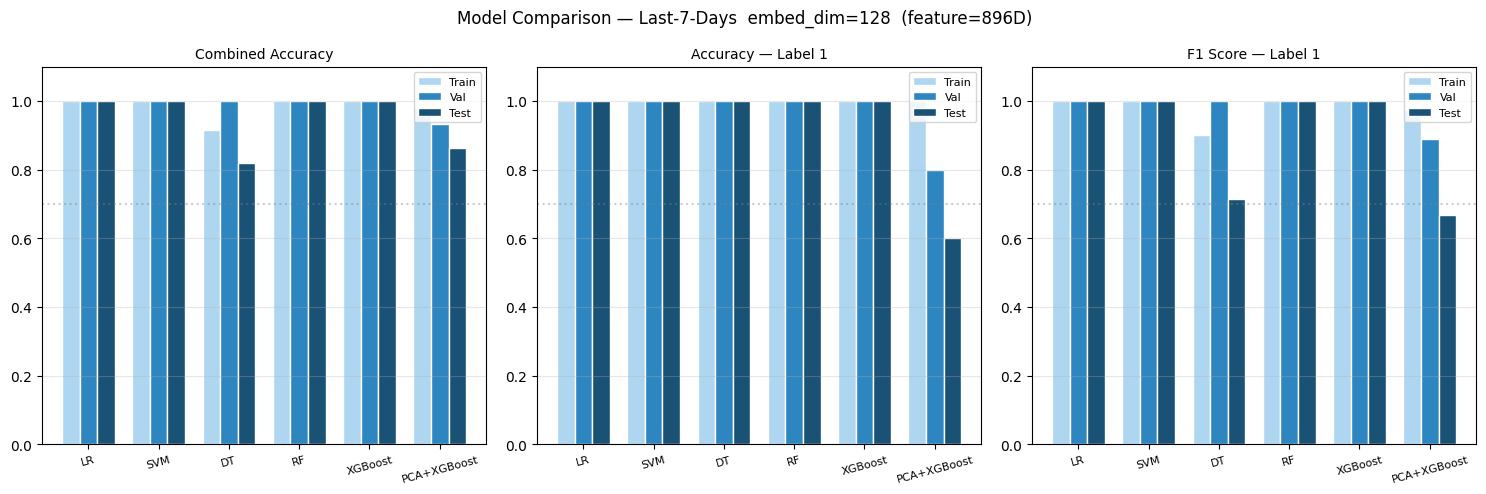


  ✅ Best model (dim=128) by val F1: LR
     Val F1=1.0000  LOGO F1=0.3294  Total time: 10.8 min

FINAL CROSS-DIM COMPARISON — Last 7 Days
   Dim  Best Model         Val F1   LOGO F1      Time
-------------------------------------------------------
    32  SVM                1.0000    0.3176      7.7m
    64  LR                 1.0000    0.3294      7.7m
   128  LR                 1.0000    0.3294     10.8m


In [ ]:
# ── Helper: timed GridSearch/RandomizedSearch with progress bar ─────────────
def fit_with_progress(search, X, y, label):
    """Fit a GridSearchCV or RandomizedSearchCV with a tqdm timer."""
    n_fits = (len(search.param_grid)
              if hasattr(search, 'param_grid')
              else search.n_iter)
    # Count actual combinations for GridSearchCV
    if hasattr(search, 'param_grid'):
        from itertools import product
        pg = search.param_grid
        n_fits = 1
        for v in pg.values(): n_fits *= len(v)
    n_fits_total = n_fits * search.cv if hasattr(search.cv, '__len__') else n_fits * 5
    print(f'  {label}: {n_fits} combos × 5 folds = {n_fits_total} fits')
    t0 = time.time()
    with tqdm(total=1, desc=f'  Fitting {label}', bar_format='{l_bar}{bar}| {elapsed}') as pbar:
        search.fit(X, y)
        pbar.update(1)
    elapsed = time.time() - t0
    print(f'  ✅ Done in {elapsed:.1f}s  Best CV F1={search.best_score_:.4f}')
    return search


# ── Main loop ─────────────────────────────────────────────────────────────────
# Dict to capture all trained estimators across dims for Step 5
all_trained_models = {}  # {embed_dim: {save_name: estimator}}

cross_dim_summary = {}
dim_pbar = tqdm(EMBED_DIMS, desc='Overall progress', unit='dim')

for EMBED_DIM in dim_pbar:
    dim_pbar.set_description(f'dim={EMBED_DIM}')
    print('\n' + '█'*70)
    print(f'  EMBED_DIM = {EMBED_DIM}  →  feature vector = {EMBED_DIM*7} dims ({EMBED_DIM}×7)')
    print('█'*70)
    dim_start = time.time()

    # ── Load embeddings ──────────────────────────────────────────────────────
    EMB_FOLDER = os.path.join(BASE_MODEL_DIR,
                     f'daily_embedding_classifier_last7days_{EMBED_DIM}dim_withtime')
    # Per-model save dirs inside 5models/last7days/{dim}dim/{model_name}/
    DIM_MODELS_DIR = os.path.join(MODELS_ROOT, f'{EMBED_DIM}dim')
    # OUT_DIR used for plots/csvs — store alongside embeddings
    OUT_DIR = os.path.join(DIM_MODELS_DIR, 'results')
    os.makedirs(OUT_DIR, exist_ok=True)

    emb_train = pd.read_parquet(os.path.join(EMB_FOLDER, 'emb_train.parquet'))
    emb_val   = pd.read_parquet(os.path.join(EMB_FOLDER, 'emb_val.parquet'))
    emb_test  = pd.read_parquet(os.path.join(EMB_FOLDER, 'emb_test.parquet'))

    EMB_COLS = [c for c in emb_train.columns if c.startswith('emb_')]
    print(f'  Loaded: train={emb_train.shape}  val={emb_val.shape}  test={emb_test.shape}')
    print(f'  Feature vector: {len(EMB_COLS)*7} dims ({len(EMB_COLS)}×7)')

    # ── Build patient-level features ─────────────────────────────────────────
    X_tr, y_tr, pids_tr = build_patient_features(emb_train, EMB_COLS, EMBED_DIM)
    X_va, y_va, pids_va = build_patient_features(emb_val,   EMB_COLS, EMBED_DIM)
    X_te, y_te, pids_te = build_patient_features(emb_test,  EMB_COLS, EMBED_DIM)
    X_tv = np.vstack([X_tr, X_va])
    y_tv = np.concatenate([y_tr, y_va])

    print(f'  Train: {X_tr.shape}  Val: {X_va.shape}  Test: {X_te.shape}')
    print(f'  Label1 — train={y_tr.sum()}  val={y_va.sum()}  test={y_te.sum()}')
    assert len(set(pids_tr) & set(pids_va)) == 0, 'Train/Val overlap!'
    assert len(set(pids_tr) & set(pids_te)) == 0, 'Train/Test overlap!'
    assert len(set(pids_va) & set(pids_te)) == 0, 'Val/Test overlap!'
    print('  ✅ No patient leakage')

    scale_pos = (y_tv == 0).sum() / max((y_tv == 1).sum(), 1)

    # ── XGBoost Stage 1: RandomizedSearchCV (100 iters) ──────────────────────
    print('\n  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...')
    xgb_rand_grid = {
        'n_estimators':     randint(50, 400),
        'max_depth':        randint(2, 5),
        'learning_rate':    uniform(0.005, 0.1),
        'subsample':        uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.4, 0.5),
        'reg_alpha':        uniform(0.0, 3.0),
        'reg_lambda':       uniform(1.0, 15.0),
        'min_child_weight': randint(3, 25),
        'gamma':            uniform(0.0, 2.0),
    }
    xgb_rand = fit_with_progress(
        RandomizedSearchCV(
            xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                               random_state=42, verbosity=0),
            xgb_rand_grid, n_iter=100, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, random_state=42, verbose=0),
        X_tv, y_tv, 'XGB-Random')
    print(f'  Best params: {xgb_rand.best_params_}')

    # ── XGBoost Stage 2: fine GridSearchCV (~512 combos) ─────────────────────
    print('\n  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...')
    xgb_fine_grid = {
        'n_estimators':     [100, 200],     # 2
        'max_depth':        [2, 3],         # 2
        'learning_rate':    [0.01, 0.02],   # 2
        'min_child_weight': [10, 15],       # 2
        'gamma':            [0.5, 1.0],     # 2
        'subsample':        [0.7, 0.8],     # 2
        'colsample_bytree': [0.5, 0.6],     # 2
        'reg_alpha':        [1.0, 2.0],     # 2
        'reg_lambda':       [8, 15],        # 2
    }  # 2^9 = 512 combos × 5 = 2560 fits
    xgb_fine = fit_with_progress(
        GridSearchCV(
            xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                               random_state=42, verbosity=0),
            xgb_fine_grid, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'XGB-Fine')
    print(f'  Best params: {xgb_fine.best_params_}')
    best_xgb = (xgb_fine.best_estimator_
                if xgb_fine.best_score_ >= xgb_rand.best_score_
                else xgb_rand.best_estimator_)
    print(f'  Using: {"fine" if xgb_fine.best_score_ >= xgb_rand.best_score_ else "random"} XGBoost')
    xgb_metrics = evaluate(best_xgb, f'XGBoost (dim={EMBED_DIM})', 'xgboost', OUT_DIR,
                           X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Logistic Regression (6 combos) ───────────────────────────────────────
    print('\n  ▶ Logistic Regression GridSearchCV (6 combos)...')
    lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced',
                                    max_iter=2000, random_state=42))
    ])
    lr_grid = {
        'clf__C':       [0.001, 0.01, 0.1],   # 3
        'clf__penalty': ['l2'],
        'clf__solver':  ['lbfgs', 'liblinear'],# 2  → 6 combos
    }
    lr_gs = fit_with_progress(
        GridSearchCV(lr_pipe, lr_grid, cv=CV, scoring=f1_scorer,
                     n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'LR')
    print(f'  Best params: {lr_gs.best_params_}')
    lr_metrics = evaluate(lr_gs, f'Logistic Regression (dim={EMBED_DIM})',
                          'logistic_regression', OUT_DIR,
                          X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Random Forest — RandomizedSearchCV (100 iters) ────────────────────────
    print('\n  ▶ Random Forest RandomizedSearchCV (100 iters)...')
    rf_rand_grid = {
        'n_estimators':      randint(100, 500),
        'max_depth':         [3, 4, 5, 6, None],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf':  randint(1, 15),
        'max_features':      ['sqrt', 'log2', 0.3, 0.5],
        'max_samples':       uniform(0.5, 0.5),
    }
    rf_rand = fit_with_progress(
        RandomizedSearchCV(
            RandomForestClassifier(class_weight='balanced',
                                    random_state=42, n_jobs=-1),
            rf_rand_grid, n_iter=100, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, random_state=42, verbose=0),
        X_tv, y_tv, 'RF-Random')
    print(f'  Best params: {rf_rand.best_params_}')
    rf_metrics = evaluate(rf_rand, f'Random Forest (dim={EMBED_DIM})',
                          'random_forest', OUT_DIR,
                          X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── SVM (12 combos) ───────────────────────────────────────────────────────
    print('\n  ▶ SVM GridSearchCV (12 combos)...')
    svm_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(class_weight='balanced', probability=True, random_state=42))
    ])
    svm_grid = {
        'clf__C':      [0.1, 1.0, 10.0],    # 3
        'clf__kernel': ['rbf', 'linear'],    # 2
        'clf__gamma':  ['scale', 'auto'],    # 2  → 12 combos
    }
    svm_gs = fit_with_progress(
        GridSearchCV(svm_pipe, svm_grid, cv=CV, scoring=f1_scorer,
                     n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'SVM')
    print(f'  Best params: {svm_gs.best_params_}')
    svm_metrics = evaluate(svm_gs, f'SVM (dim={EMBED_DIM})', 'svm', OUT_DIR,
                           X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Decision Tree (24 combos) ─────────────────────────────────────────────
    print('\n  ▶ Decision Tree GridSearchCV (24 combos)...')
    dt_grid = {
        'max_depth':         [3, 5, None],       # 3
        'min_samples_split': [5, 10],             # 2
        'min_samples_leaf':  [3, 5],              # 2
        'max_features':      ['sqrt', 'log2'],    # 2  → 24 combos
        'class_weight':      ['balanced'],
    }
    dt_gs = fit_with_progress(
        GridSearchCV(
            DecisionTreeClassifier(random_state=42),
            dt_grid, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'DT')
    print(f'  Best params: {dt_gs.best_params_}')
    dt_metrics = evaluate(dt_gs, f'Decision Tree (dim={EMBED_DIM})',
                          'decision_tree', OUT_DIR,
                          X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── PCA + XGBoost (128 combos) ────────────────────────────────────────────
    print('\n  ▶ PCA + XGBoost GridSearchCV (128 combos)...')
    max_pca = min(30, X_tv.shape[0] - 1, X_tv.shape[1])
    pca_candidates = [c for c in [10, 20] if c <= max_pca]  # 2
    pca_xgb_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(random_state=42)),
        ('clf',    xgb.XGBClassifier(scale_pos_weight=scale_pos,
                                      eval_metric='logloss',
                                      random_state=42, verbosity=0))
    ])
    pca_xgb_grid = {
        'pca__n_components':     pca_candidates,       # 2
        'clf__n_estimators':     [100, 200],            # 2
        'clf__max_depth':        [2, 3],                # 2
        'clf__learning_rate':    [0.01, 0.05],          # 2
        'clf__min_child_weight': [5, 10],               # 2
        'clf__reg_alpha':        [0.5, 2.0],            # 2
        'clf__reg_lambda':       [5, 10],               # 2
    }  # 2^7 = 128 combos × 5 = 640 fits
    pca_xgb_gs = fit_with_progress(
        GridSearchCV(pca_xgb_pipe, pca_xgb_grid, cv=CV, scoring=f1_scorer,
                     n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'PCA+XGB')
    print(f'  Best params: {pca_xgb_gs.best_params_}')
    pca_xgb_metrics = evaluate(pca_xgb_gs, f'PCA+XGBoost (dim={EMBED_DIM})',
                                'pca_xgboost', OUT_DIR,
                                X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Capture trained models for Step 5 saving ───────────────────────────────
    all_trained_models[EMBED_DIM] = {
        'xgboost':              {'clf': best_xgb,    'save_dir': os.path.join(DIM_MODELS_DIR, 'xgboost')},
        'logistic_regression':  {'clf': lr_gs,       'save_dir': os.path.join(DIM_MODELS_DIR, 'logistic_regression')},
        'random_forest':        {'clf': rf_rand,     'save_dir': os.path.join(DIM_MODELS_DIR, 'random_forest')},
        'svm':                  {'clf': svm_gs,      'save_dir': os.path.join(DIM_MODELS_DIR, 'svm')},
        'decision_tree':        {'clf': dt_gs,       'save_dir': os.path.join(DIM_MODELS_DIR, 'decision_tree')},
        'pca_xgboost':          {'clf': pca_xgb_gs, 'save_dir': os.path.join(DIM_MODELS_DIR, 'pca_xgboost')},
    }
    print(f'  ✅ Models captured for dim={EMBED_DIM} → Step 5 can now save them')

    # ── LOGO-CV with progress bar ─────────────────────────────────────────────
    print('\n  ▶ Leave-One-Patient-Out CV...')
    X_all_pat = np.vstack([X_tr, X_va, X_te])
    y_all_pat = np.concatenate([y_tr, y_va, y_te])
    pids_all  = np.concatenate([pids_tr, pids_va, pids_te])
    logo      = LeaveOneGroupOut()

    logo_results = {}
    logo_models = [
        ('XGBoost',     best_xgb),
        ('LR',          lr_gs.best_estimator_),
        ('RF',          rf_rand.best_estimator_),
        ('SVM',         svm_gs.best_estimator_),
        ('DT',          dt_gs.best_estimator_),
        ('PCA+XGBoost', pca_xgb_gs.best_estimator_),
    ]
    for model_name, clf in tqdm(logo_models, desc='  LOGO-CV', leave=False):
        t0 = time.time()
        scores = cross_val_score(
            clf, X_all_pat, y_all_pat,
            cv=logo, groups=pids_all,
            scoring=f1_scorer, n_jobs=-1)
        elapsed = time.time() - t0
        logo_results[model_name] = scores.mean()
        print(f'  {model_name:<15}  LOGO F1: '
              f'{scores.mean():.4f} ± {scores.std():.4f}  '
              f'min={scores.min():.3f}  max={scores.max():.3f}  '
              f'({elapsed:.1f}s)')

    # ── Summary table ─────────────────────────────────────────────────────────
    all_models = [
        ('LR',          lr_metrics),
        ('SVM',         svm_metrics),
        ('DT',          dt_metrics),
        ('RF',          rf_metrics),
        ('XGBoost',     xgb_metrics),
        ('PCA+XGBoost', pca_xgb_metrics),
    ]

    for split_name in ['Train', 'Val', 'Test']:
        print(f'\n{"="*65}')
        print(f'  ACCURACY TABLE — dim={EMBED_DIM}  {split_name}')
        print(f'{"="*65}')
        header = f'{"Metric":<14}' + ''.join(f'{n:>12}' for n, _ in all_models)
        print(header)
        print('-'*65)
        for row_label, key in [
            ('Accuracy',   'acc'),
            ('Acc L0',     'acc0'),
            ('Acc L1',     'acc1'),
            ('F1 (L1)',    'f1'),
            ('AUROC',      'auc'),
        ]:
            row = f'{row_label:<14}'
            for _, m in all_models:
                val = m[split_name].get(key, float('nan'))
                row += f'{val:>12.4f}'
            print(row)

    # Summary DataFrame + CSV
    summary_rows = []
    for mname, m in all_models:
        for split in ['Train', 'Val', 'Test']:
            summary_rows.append({
                'embed_dim': EMBED_DIM,
                'model':     mname,
                'split':     split,
                'acc':       m[split]['acc'],
                'acc_L0':    m[split]['acc0'],
                'acc_L1':    m[split]['acc1'],
                'f1_L1':     m[split]['f1'],
                'auroc':     m[split]['auc'],
                'logo_f1':   logo_results.get(mname, float('nan')),
            })
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(os.path.join(OUT_DIR, f'summary_{EMBED_DIM}dim.csv'), index=False)

    # Bar chart
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Model Comparison — Last-7-Days  embed_dim={EMBED_DIM}  '
                 f'(feature={EMBED_DIM*7}D)', fontsize=12)
    model_names = [n for n, _ in all_models]
    x = np.arange(len(model_names))
    w = 0.25
    colors = ['#AED6F1', '#2E86C1', '#1A5276']
    for ax, metric, title in [
        (axes[0], 'acc',    'Combined Accuracy'),
        (axes[1], 'acc_L1', 'Accuracy — Label 1'),
        (axes[2], 'f1_L1',  'F1 Score — Label 1'),
    ]:
        for i, (split, color) in enumerate(zip(['Train','Val','Test'], colors)):
            vals = [summary_df[(summary_df['model']==m) &
                               (summary_df['split']==split)][metric].values[0]
                    for m in model_names]
            ax.bar(x + (i-1)*w, vals, w, label=split, color=color, edgecolor='white')
        ax.set_title(title, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, fontsize=8, rotation=15)
        ax.set_ylim(0, 1.1)
        ax.axhline(0.7, color='gray', linestyle=':', alpha=0.4)
        ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'model_comparison_{EMBED_DIM}dim.png'), dpi=150)
    plt.show()

    dim_elapsed = time.time() - dim_start
    best_row = (summary_df[summary_df['split']=='Val']
                .sort_values('f1_L1', ascending=False).iloc[0])
    print(f'\n  ✅ Best model (dim={EMBED_DIM}) by val F1: {best_row["model"]}')
    print(f'     Val F1={best_row["f1_L1"]:.4f}  '
          f'LOGO F1={logo_results.get(best_row["model"], float("nan")):.4f}  '
          f'Total time: {dim_elapsed/60:.1f} min')

    cross_dim_summary[EMBED_DIM] = {
        'best_model': best_row['model'],
        'val_f1':     best_row['f1_L1'],
        'logo_f1':    logo_results.get(best_row['model'], float('nan')),
        'time_min':   round(dim_elapsed/60, 1),
        'summary_df': summary_df,
        'out_dir':    OUT_DIR,
        'dim_models_dir': DIM_MODELS_DIR,
    }

# ── Final cross-dim comparison ────────────────────────────────────────────────
print('\n' + '='*70)
print('FINAL CROSS-DIM COMPARISON — Last 7 Days')
print('='*70)
print(f'{"Dim":>6}  {"Best Model":<15}  {"Val F1":>8}  {"LOGO F1":>8}  {"Time":>8}')
print('-'*55)
for dim, res in cross_dim_summary.items():
    print(f'{dim:>6}  {res["best_model"]:<15}  '
          f'{res["val_f1"]:>8.4f}  {res["logo_f1"]:>8.4f}  '
          f'{res["time_min"]:>7.1f}m')


---
## Step 5 — Save All 18 Trained Models

Run immediately after Step 4 (same session — models live in memory).
Saves each model to its own subfolder with:
- `model.joblib` — the trained estimator
- `best_params.json` — best hyperparameters found
- `metrics.json` — train / val / test accuracy, F1, AUROC

**Folder structure:**
```
5models/last7days_withtime/
  32dim/
    xgboost/            model.joblib  best_params.json  metrics.json
    logistic_regression/
    random_forest/
    svm/
    decision_tree/
    pca_xgboost/
  64dim/  ...
  128dim/ ...
```

**To reload later (no re-training):**
```python
import joblib
model = joblib.load('.../5models/last7days/32dim/xgboost/model.joblib')
preds = model.predict(X_te)
probs = model.predict_proba(X_te)[:, 1]
```


In [ ]:
import joblib, json as _json

MODEL_LABELS = {
    'xgboost':             'XGBoost',
    'logistic_regression': 'Logistic Regression',
    'random_forest':       'Random Forest',
    'svm':                 'SVM',
    'decision_tree':       'Decision Tree',
    'pca_xgboost':         'PCA + XGBoost',
}

total_saved = 0
save_errors = []
n_total     = len(EMBED_DIMS) * len(MODEL_LABELS)  # 18

print('Saving trained models...')
print(f'Target: {n_total} models  ({len(EMBED_DIMS)} dims × {len(MODEL_LABELS)} models)')
print('='*65)

for EMBED_DIM in EMBED_DIMS:
    if EMBED_DIM not in all_trained_models:
        print(f'\n  ⚠️  dim={EMBED_DIM} not in all_trained_models — skipping')
        continue

    print(f'\n  ── dim={EMBED_DIM} ──────────────────────────────────────────')

    # Retrieve metrics from cross_dim_summary for this dim
    summary_df = cross_dim_summary[EMBED_DIM]['summary_df']

    for save_name, entry in all_trained_models[EMBED_DIM].items():
        clf      = entry['clf']
        save_dir = entry['save_dir']
        label    = MODEL_LABELS.get(save_name, save_name)
        os.makedirs(save_dir, exist_ok=True)

        try:
            # 1) Save model
            model_path = os.path.join(save_dir, 'model.joblib')
            joblib.dump(clf, model_path, compress=3)
            size_kb = os.path.getsize(model_path) / 1024

            # 2) Save best hyperparameters
            params = {}
            if hasattr(clf, 'best_params_'):
                params = {str(k): str(v) for k, v in clf.best_params_.items()}
            elif hasattr(clf, 'get_params'):
                params = {str(k): str(v) for k, v in clf.get_params().items()}
            with open(os.path.join(save_dir, 'best_params.json'), 'w') as f:
                _json.dump(params, f, indent=2)

            # 3) Save metrics (train/val/test)
            # Map save_name → summary_df model name
            name_map = {
                'xgboost':             'XGBoost',
                'logistic_regression': 'LR',
                'random_forest':       'RF',
                'svm':                 'SVM',
                'decision_tree':       'DT',
                'pca_xgboost':         'PCA+XGBoost',
            }
            mname  = name_map.get(save_name, save_name)
            m_rows = summary_df[summary_df['model'] == mname]
            metrics_out = {}
            for _, row in m_rows.iterrows():
                metrics_out[row['split']] = {
                    'accuracy':  round(float(row['acc']),    4),
                    'acc_L0':    round(float(row['acc_L0']), 4),
                    'acc_L1':    round(float(row['acc_L1']), 4),
                    'f1_L1':     round(float(row['f1_L1']),  4),
                    'auroc':     round(float(row['auroc']),  4),
                    'logo_f1':   round(float(row['logo_f1']),4),
                }
            with open(os.path.join(save_dir, 'metrics.json'), 'w') as f:
                _json.dump(metrics_out, f, indent=2)

            print(f'    ✅  {label:<25}  model.joblib ({size_kb:.0f} KB)')
            total_saved += 1

        except Exception as e:
            print(f'    ❌  {label}: {e}')
            save_errors.append((EMBED_DIM, save_name, str(e)))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'✅  Saved : {total_saved} / {n_total} models')
if save_errors:
    print(f'❌  Errors: {save_errors}')
else:
    print('   No errors.')

# ── Verify folder structure on disk ──────────────────────────────────────────
print(f'\nFolder structure ({MODELS_ROOT}):')
for dim in EMBED_DIMS:
    dim_dir = os.path.join(MODELS_ROOT, f'{dim}dim')
    print(f'  {dim}dim/')
    for mname in MODEL_NAMES:
        mdir   = os.path.join(dim_dir, mname)
        files  = os.listdir(mdir) if os.path.exists(mdir) else []
        status = '✅' if 'model.joblib' in files else '❌'
        size_kb = (os.path.getsize(os.path.join(mdir,'model.joblib'))/1024
                   if 'model.joblib' in files else 0)
        print(f'    {status}  {mname:<25} {sorted(files)}  ({size_kb:.0f} KB)')


Saving trained models...
Target: 18 models  (3 dims × 6 models)

  ── dim=32 ──────────────────────────────────────────
    ✅  XGBoost                    model.joblib (13 KB)
    ✅  Logistic Regression        model.joblib (9 KB)
    ✅  Random Forest              model.joblib (34 KB)
    ✅  SVM                        model.joblib (25 KB)
    ✅  Decision Tree              model.joblib (3 KB)
    ✅  PCA + XGBoost              model.joblib (34 KB)

  ── dim=64 ──────────────────────────────────────────
    ✅  XGBoost                    model.joblib (11 KB)
    ✅  Logistic Regression        model.joblib (15 KB)
    ✅  Random Forest              model.joblib (29 KB)
    ✅  SVM                        model.joblib (30 KB)
    ✅  Decision Tree              model.joblib (2 KB)
    ✅  PCA + XGBoost              model.joblib (40 KB)

  ── dim=128 ──────────────────────────────────────────
    ✅  XGBoost                    model.joblib (11 KB)
    ✅  Logistic Regression        model.joblib (28 KB)


##Reload

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import f1_score, roc_auc_score

# ── Config (same as Step 2) ───────────────────────────────────────────────────
BASE_MODEL_DIR = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model"
MODELS_ROOT    = os.path.join(BASE_MODEL_DIR, 'classifier_5models', 'last7days_withtime')
EMBED_DIMS     = [32, 64, 128]
ALL_DAYS       = list(range(7))

MODEL_SAVE_NAMES = [
    'xgboost', 'logistic_regression', 'random_forest',
    'svm', 'decision_tree', 'pca_xgboost'
]
name_map_rev = {
    'xgboost':             'XGBoost',
    'logistic_regression': 'LR',
    'random_forest':       'RF',
    'svm':                 'SVM',
    'decision_tree':       'DT',
    'pca_xgboost':         'PCA+XGBoost',
}

# ── Re-define build_patient_features ─────────────────────────────────────────
def build_patient_features(emb_df, emb_cols, emb_dim):
    patient_ids = emb_df['patient_id'].unique()
    X_rows, y_rows, pids_out = [], [], []
    for pid in patient_ids:
        sub   = emb_df[emb_df['patient_id'] == pid]
        label = int(sub['label'].iloc[0])
        day_vecs = []
        for d in ALL_DAYS:
            rows = sub[sub['unified_day'] == d]
            vec  = rows[emb_cols].values.mean(axis=0).astype(np.float32) \
                   if len(rows) > 0 else np.zeros(emb_dim, dtype=np.float32)
            day_vecs.append(vec)
        X_rows.append(np.concatenate(day_vecs))
        y_rows.append(label)
        pids_out.append(pid)
    return np.array(X_rows), np.array(y_rows), np.array(pids_out)

# ── Reload all_trained_models from saved .joblib files ───────────────────────
all_trained_models = {}
for EMBED_DIM in EMBED_DIMS:
    all_trained_models[EMBED_DIM] = {}
    for save_name in MODEL_SAVE_NAMES:
        model_path = os.path.join(MODELS_ROOT, f'{EMBED_DIM}dim', save_name, 'model.joblib')
        clf = joblib.load(model_path)
        save_dir = os.path.join(MODELS_ROOT, f'{EMBED_DIM}dim', save_name)
        all_trained_models[EMBED_DIM][save_name] = {'clf': clf, 'save_dir': save_dir}
        print(f'  Loaded dim={EMBED_DIM}  {save_name}')

# ── Reload cross_dim_summary from saved summary CSVs ─────────────────────────
cross_dim_summary = {}
for EMBED_DIM in EMBED_DIMS:
    out_dir  = os.path.join(MODELS_ROOT, f'{EMBED_DIM}dim', 'results')
    csv_path = os.path.join(out_dir, f'summary_{EMBED_DIM}dim.csv')
    summary_df = pd.read_csv(csv_path)
    cross_dim_summary[EMBED_DIM] = {
        'summary_df': summary_df,
        'out_dir':    out_dir,
    }
    print(f'  Loaded summary dim={EMBED_DIM}  ({len(summary_df)} rows)')

print('\n✅ All models and summaries reloaded — ready to run Step 6')

Mounted at /content/drive
  Loaded dim=32  xgboost
  Loaded dim=32  logistic_regression
  Loaded dim=32  random_forest
  Loaded dim=32  svm
  Loaded dim=32  decision_tree
  Loaded dim=32  pca_xgboost
  Loaded dim=64  xgboost
  Loaded dim=64  logistic_regression
  Loaded dim=64  random_forest
  Loaded dim=64  svm
  Loaded dim=64  decision_tree
  Loaded dim=64  pca_xgboost
  Loaded dim=128  xgboost
  Loaded dim=128  logistic_regression
  Loaded dim=128  random_forest
  Loaded dim=128  svm
  Loaded dim=128  decision_tree
  Loaded dim=128  pca_xgboost
  Loaded summary dim=32  (18 rows)
  Loaded summary dim=64  (18 rows)
  Loaded summary dim=128  (18 rows)

✅ All models and summaries reloaded — ready to run Step 6


## Step 6

In [4]:
## Step 6 — Bootstrap 95% CIs on Test Set + Summary Table for Paper
#
# WHY PATIENT-LEVEL BOOTSTRAP:
#   Transformer embeddings are fixed (pre-computed). We cannot resample
#   at the waveform level without re-running the Transformer. Instead we
#   resample *patients* with replacement from the test set and re-predict
#   using the frozen classifier. This gives valid CIs for classifier
#   performance under sampling variability.
#   Disclosure: "Bootstrap CIs reflect patient-level resampling of the
#   test set; embedding representations are fixed."
#
# WHAT THIS ADDS (per feedback 1.1):
#   - Bootstrap 95% CI for F1 (label 1) on the test set
#   - Bootstrap 95% CI for AUROC on the test set
#   - LOGO-CV mean ± std (already computed in Step 4 — surfaced here)
#   - Final paper-ready summary table across all dims × models

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score

# ── Config ────────────────────────────────────────────────────────────────────
N_BOOTSTRAP   = 2000   # 2000 resamples gives stable 95% CI
RANDOM_SEED   = 42
ALPHA         = 0.05   # two-sided 95%

rng = np.random.default_rng(RANDOM_SEED)


def bootstrap_ci_test(clf, X_te, y_te, n_bootstrap=N_BOOTSTRAP, alpha=ALPHA):
    """
    Patient-level bootstrap CI for F1 (label 1) and AUROC on a fixed test set.

    Parameters
    ----------
    clf         : fitted sklearn estimator (classifier with predict_proba)
    X_te        : np.ndarray, shape [n_patients, n_features]
    y_te        : np.ndarray, shape [n_patients]
    n_bootstrap : int
    alpha       : float (e.g. 0.05 for 95% CI)

    Returns
    -------
    dict with keys: f1_mean, f1_lower, f1_upper, auc_mean, auc_lower, auc_upper
    """
    n = len(y_te)
    f1_scores  = np.empty(n_bootstrap)
    auc_scores = np.empty(n_bootstrap)

    # Pre-compute probabilities once (classifier is frozen)
    try:
        probs_all = clf.predict_proba(X_te)[:, 1]
    except AttributeError:
        probs_all = clf.decision_function(X_te)

    for i in range(n_bootstrap):
        # Resample patient indices with replacement
        idx = rng.integers(0, n, size=n)
        y_boot    = y_te[idx]
        prob_boot = probs_all[idx]
        pred_boot = (prob_boot >= 0.5).astype(int)

        # Skip degenerate bootstrap samples (only one class present)
        if len(np.unique(y_boot)) < 2:
            f1_scores[i]  = np.nan
            auc_scores[i] = np.nan
            continue

        f1_scores[i]  = f1_score(y_boot, pred_boot, pos_label=1, zero_division=0)
        try:
            auc_scores[i] = roc_auc_score(y_boot, prob_boot)
        except ValueError:
            auc_scores[i] = np.nan

    # Drop NaN samples (degenerate draws — rare with enough label-1 patients)
    f1_valid  = f1_scores[~np.isnan(f1_scores)]
    auc_valid = auc_scores[~np.isnan(auc_scores)]

    lo, hi = alpha / 2, 1 - alpha / 2
    return {
        'f1_point':   round(float(f1_score(y_te, (probs_all >= 0.5).astype(int),
                                            pos_label=1, zero_division=0)), 4),
        'f1_mean':    round(float(np.mean(f1_valid)),              4),
        'f1_lower':   round(float(np.quantile(f1_valid,  lo)),     4),
        'f1_upper':   round(float(np.quantile(f1_valid,  hi)),     4),
        'auc_point':  round(float(roc_auc_score(y_te, probs_all)), 4),
        'auc_mean':   round(float(np.mean(auc_valid)),             4),
        'auc_lower':  round(float(np.quantile(auc_valid, lo)),     4),
        'auc_upper':  round(float(np.quantile(auc_valid, hi)),     4),
        'n_valid_bootstrap': int(len(f1_valid)),
    }


# ── Run bootstrap for every dim × model ──────────────────────────────────────
# Requires: all_trained_models, cross_dim_summary, and per-dim X_te / y_te / pids_te
# We reload X_te for each dim inside the loop (same logic as Step 4).

print('Running patient-level bootstrap CIs (2000 resamples per model)...')
print(f'Note: embeddings are fixed; CIs reflect patient-level sampling variability.\n')

ci_rows = []

for EMBED_DIM in EMBED_DIMS:
    print(f'\n── dim={EMBED_DIM} ──────────────────────────────────────────────')

    # Reload test embeddings for this dim (same path as Step 4)
    EMB_FOLDER = os.path.join(BASE_MODEL_DIR,
                     f'daily_embedding_classifier_last7days_{EMBED_DIM}dim_withtime')
    emb_test_ci = pd.read_parquet(os.path.join(EMB_FOLDER, 'emb_test.parquet'))
    EMB_COLS_CI = [c for c in emb_test_ci.columns if c.startswith('emb_')]
    X_te_ci, y_te_ci, pids_te_ci = build_patient_features(
        emb_test_ci, EMB_COLS_CI, EMBED_DIM)

    print(f'  Test set: {len(y_te_ci)} patients  '
          f'(label-0: {(y_te_ci==0).sum()}  label-1: {(y_te_ci==1).sum()})')

    # Retrieve LOGO-CV results for this dim
    logo_res = {}
    # logo_results was computed in Step 4; re-run LOGO here if not available
    # (if you re-run Step 6 standalone, re-run the LOGO block from Step 4 first)

    name_map_rev = {
        'xgboost':             'XGBoost',
        'logistic_regression': 'LR',
        'random_forest':       'RF',
        'svm':                 'SVM',
        'decision_tree':       'DT',
        'pca_xgboost':         'PCA+XGBoost',
    }

    for save_name, entry in all_trained_models[EMBED_DIM].items():
        clf_ci   = entry['clf']
        mname    = name_map_rev[save_name]

        ci = bootstrap_ci_test(clf_ci, X_te_ci, y_te_ci)

        # Pull LOGO-CV mean ± std from cross_dim_summary
        sumdf = cross_dim_summary[EMBED_DIM]['summary_df']
        logo_row = sumdf[(sumdf['model'] == mname) & (sumdf['split'] == 'Test')]
        logo_f1  = logo_row['logo_f1'].values[0] if len(logo_row) > 0 else float('nan')

        print(f'  {mname:<15}  '
              f'F1={ci["f1_point"]:.3f} [95% CI {ci["f1_lower"]:.3f}–{ci["f1_upper"]:.3f}]  '
              f'AUC={ci["auc_point"]:.3f} [95% CI {ci["auc_lower"]:.3f}–{ci["auc_upper"]:.3f}]  '
              f'LOGO-F1={logo_f1:.3f}')

        ci_rows.append({
            'embed_dim':      EMBED_DIM,
            'model':          mname,
            'n_test_patients': int(len(y_te_ci)),
            'n_label1_test':  int((y_te_ci == 1).sum()),
            # Point estimates
            'f1_point':       ci['f1_point'],
            'auc_point':      ci['auc_point'],
            # Bootstrap CIs
            'f1_lower_95':    ci['f1_lower'],
            'f1_upper_95':    ci['f1_upper'],
            'auc_lower_95':   ci['auc_lower'],
            'auc_upper_95':   ci['auc_upper'],
            # LOGO-CV (already patient-exclusive)
            'logo_f1':        round(float(logo_f1), 4),
        })

ci_df = pd.DataFrame(ci_rows)

# ── Save CSV ──────────────────────────────────────────────────────────────────
for EMBED_DIM in EMBED_DIMS:
    out_dir_ci = cross_dim_summary[EMBED_DIM]['out_dir']
    subset = ci_df[ci_df['embed_dim'] == EMBED_DIM]
    subset.to_csv(os.path.join(out_dir_ci, f'bootstrap_ci_{EMBED_DIM}dim.csv'), index=False)
    print(f'\nSaved: bootstrap_ci_{EMBED_DIM}dim.csv → {out_dir_ci}')

# ── Paper-ready summary table ─────────────────────────────────────────────────
print('\n' + '='*80)
print('PAPER-READY TABLE: Test-set F1 with 95% Bootstrap CI + LOGO-CV F1')
print('(Use this to replace the single point estimates in Table I)')
print('='*80)
print(f'{"Dim":>5}  {"Model":<15}  {"Test F1 [95% CI]":<26}  '
      f'{"Test AUC [95% CI]":<26}  {"LOGO F1":>8}')
print('-'*90)
for _, row in ci_df.sort_values(['embed_dim', 'model']).iterrows():
    f1_str  = f'{row["f1_point"]:.3f} [{row["f1_lower_95"]:.3f}–{row["f1_upper_95"]:.3f}]'
    auc_str = f'{row["auc_point"]:.3f} [{row["auc_lower_95"]:.3f}–{row["auc_upper_95"]:.3f}]'
    print(f'{int(row["embed_dim"]):>5}  {row["model"]:<15}  {f1_str:<26}  '
          f'{auc_str:<26}  {row["logo_f1"]:>8.3f}')

print('\nNote on interpretation:')
print('  - Test F1/AUC: point estimate on held-out test patients, with 95% CI')
print('    from 2000 patient-level bootstrap resamples (embeddings fixed).')
print('  - LOGO F1: leave-one-patient-out CV across all patients (most conservative).')
print('  - For the paper, report LOGO F1 as the primary cross-validated metric.')
print('  - Bootstrap CI on the test set shows the uncertainty of that point estimate.')

Running patient-level bootstrap CIs (2000 resamples per model)...
Note: embeddings are fixed; CIs reflect patient-level sampling variability.


── dim=32 ──────────────────────────────────────────────
  Test set: 22 patients  (label-0: 17  label-1: 5)
  XGBoost          F1=0.800 [95% CI 0.400–1.000]  AUC=0.988 [95% CI 0.930–1.000]  LOGO-F1=0.318
  LR               F1=0.909 [95% CI 0.667–1.000]  AUC=0.988 [95% CI 0.935–1.000]  LOGO-F1=0.318
  RF               F1=0.769 [95% CI 0.400–1.000]  AUC=0.977 [95% CI 0.900–1.000]  LOGO-F1=0.329
  SVM              F1=0.800 [95% CI 0.333–1.000]  AUC=0.918 [95% CI 0.695–1.000]  LOGO-F1=0.318
  DT               F1=0.750 [95% CI 0.000–1.000]  AUC=0.753 [95% CI 0.424–1.000]  LOGO-F1=0.294
  PCA+XGBoost      F1=0.667 [95% CI 0.250–0.933]  AUC=0.871 [95% CI 0.604–1.000]  LOGO-F1=0.259

── dim=64 ──────────────────────────────────────────────
  Test set: 22 patients  (label-0: 17  label-1: 5)
  XGBoost          F1=1.000 [95% CI 1.000–1.000]  AUC=1.000 [95